<a href="https://colab.research.google.com/github/AND-SHAL-0813/vehicle-object-counter-yolov8/blob/main/vehicle_object_counter_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# 1. Install YOLOv8 framework and vision tools
!pip install ultralytics opencv-python pandas matplotlib
print("Libraries installed successfully!")

Libraries installed successfully!


In [10]:
import urllib.request
import os

# Create workspace folders
os.makedirs("inputs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Download sample traffic image
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

image_url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
urllib.request.urlretrieve(image_url, "inputs/sample_traffic.jpg")

print("Folders created and sample image saved to inputs/sample_traffic.jpg")

Folders created and sample image saved to inputs/sample_traffic.jpg


In [11]:
# Interactive input box to enter expected vehicle count
expected_count = int(input("Enter the expected number of vehicles/objects in the image: "))
print(f"Recorded Expected Count: {expected_count}")

Enter the expected number of vehicles/objects in the image: 3
Recorded Expected Count: 3


=== 1. ORIGINAL CAPTURED IMAGE (EXPECTED VEHICLES: 3) ===


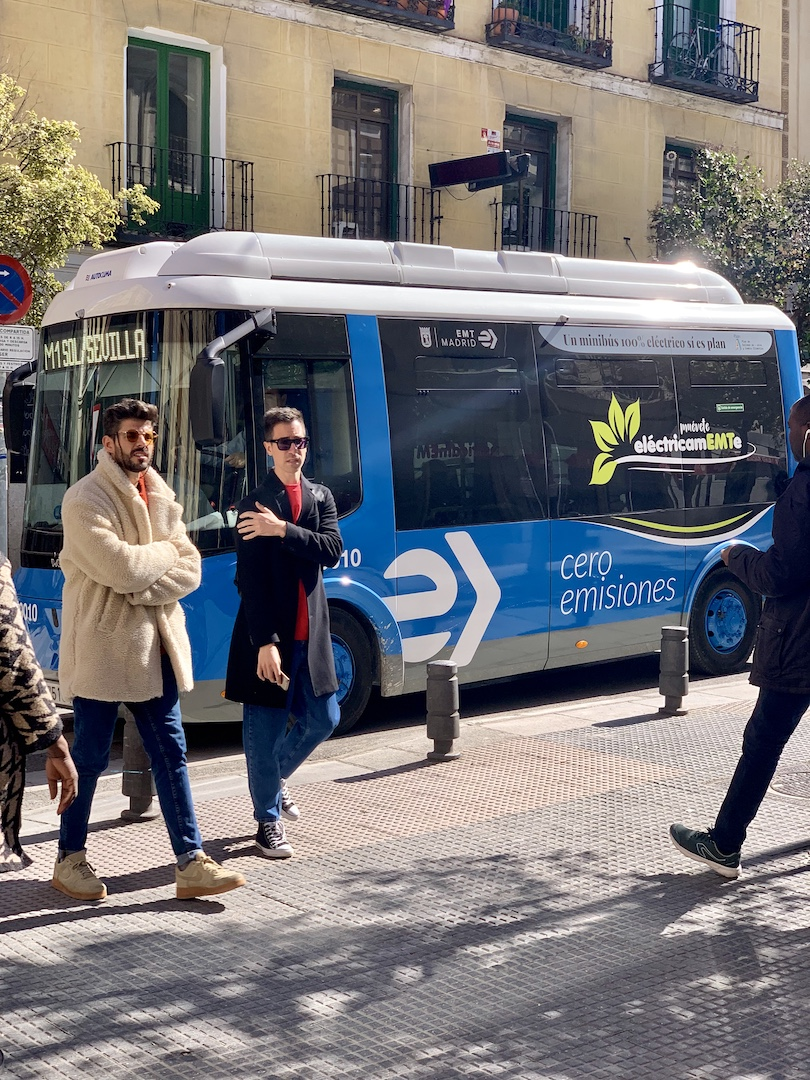

In [12]:
import cv2
from google.colab.patches import cv2_imshow

# Load and display original input image
original_image = cv2.imread("inputs/sample_traffic.jpg")

print(f"=== 1. ORIGINAL CAPTURED IMAGE (EXPECTED VEHICLES: {expected_count}) ===")
cv2_imshow(original_image)

=== 2. FINAL CONCLUDED IMAGE (WITH BOUNDING BOXES & COUNT COMPARISON) ===


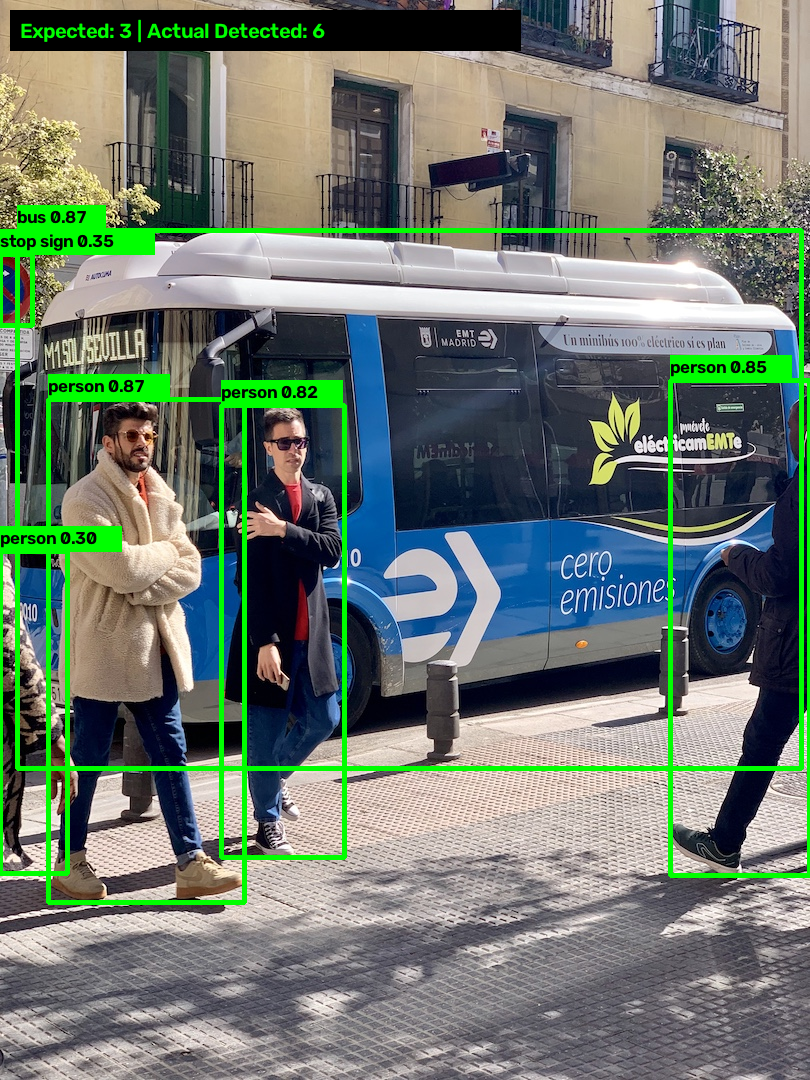


Final Count Summary -> Expected: 3 | Actual AI Count: 6
Results saved successfully to 'outputs/vehicle_counts.csv'!


In [13]:
import cv2
import pandas as pd
from datetime import datetime
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

image_path = "inputs/sample_traffic.jpg"
annotated_image = cv2.imread(image_path)

# Run object recognition
results = model(image_path, verbose=False)[0]

actual_count = 0
class_counts = {}

# Draw bounding boxes
for box in results.boxes:
    actual_count += 1
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    confidence = float(box.conf[0])
    label = f"{class_name} {confidence:.2f}"

    # Draw green bounding box
    cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.rectangle(annotated_image, (x1, y1 - 25), (x1 + len(label)*11, y1), (0, 255, 0), -1)
    cv2.putText(annotated_image, label, (x1, y1 - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

# Banner overlay: display expected vs actual count
banner_text = f"Expected: {expected_count} | Actual Detected: {actual_count}"
cv2.rectangle(annotated_image, (10, 10), (520, 50), (0, 0, 0), -1)
cv2.putText(annotated_image, banner_text, (20, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Display final concluded image
print("=== 2. FINAL CONCLUDED IMAGE (WITH BOUNDING BOXES & COUNT COMPARISON) ===")
cv2_imshow(annotated_image)

# Save annotated image and log to CSV
cv2.imwrite("outputs/annotated_traffic.jpg", annotated_image)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
summary_data = [{
    "Expected_Count": expected_count,
    "Actual_Detected_Count": actual_count,
    "Category": k,
    "Category_Count": v,
    "Timestamp": timestamp
} for k, v in class_counts.items()]

df = pd.DataFrame(summary_data)
df.to_csv("outputs/vehicle_counts.csv", index=False)

print(f"\nFinal Count Summary -> Expected: {expected_count} | Actual AI Count: {actual_count}")
print("Results saved successfully to 'outputs/vehicle_counts.csv'!")